In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Load the Pima Indians Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values:
P

In [4]:
print("Outcome Distribution:")
print(df["Outcome"].value_counts())

print("\nOutcome Percentage:")
print(df["Outcome"].value_counts(normalize=True) * 100)

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [5]:
# Input features
X = df.drop("Outcome", axis=1)

# Target variable
y = df["Outcome"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (768, 8)
Target Shape: (768,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [7]:
# Create logistic regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
# Predict classes for test data
y_pred = logistic_model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 1 0]


In [9]:
accuracy_without_scaling = accuracy_score(y_test, y_pred)
precision_without_scaling = precision_score(y_test, y_pred)
recall_without_scaling = recall_score(y_test, y_pred)
f1_without_scaling = f1_score(y_test, y_pred)

print("Performance Without Feature Scaling")
print("------------------------------------")
print("Accuracy :", accuracy_without_scaling)
print("Precision:", precision_without_scaling)
print("Recall   :", recall_without_scaling)
print("F1-Score :", f1_without_scaling)

Performance Without Feature Scaling
------------------------------------
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1-Score : 0.56


In [10]:
scaler = StandardScaler()

In [11]:
# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform test data
X_test_scaled = scaler.transform(X_test)

print("First 5 scaled training samples:")
print(X_train_scaled[:5])

First 5 scaled training samples:
[[-0.85135507 -0.98013068 -0.40478372 -0.55397256 -0.33131928 -0.60767846
   0.31079384 -0.79216928]
 [ 0.35657564  0.16144422  0.46536842  0.392787   -0.52639809 -0.30213902
  -0.11643851  0.56103382]
 [-0.5493724  -0.50447447 -0.62232176  1.21331196  0.14244354  0.3725939
  -0.76486207 -0.70759409]
 [-0.85135507  0.7956525  -0.73109078 -1.31138021 -0.73076636 -0.28940821
   0.26231357 -0.36929331]
 [-1.15333775 -0.82157861 -0.29601471  1.15019465  0.24462767  1.60748245
  -0.33762972 -0.96131967]]


In [12]:
# Create logistic regression model
scaled_logistic_model = LogisticRegression(max_iter=1000)

# Train using scaled features
scaled_logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
# Predict using scaled test data
y_pred_scaled = scaled_logistic_model.predict(X_test_scaled)

print("Predicted Values:")
print(y_pred_scaled)

Predicted Values:
[1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 1 0]


In [14]:
accuracy_with_scaling = accuracy_score(y_test, y_pred_scaled)
precision_with_scaling = precision_score(y_test, y_pred_scaled)
recall_with_scaling = recall_score(y_test, y_pred_scaled)
f1_with_scaling = f1_score(y_test, y_pred_scaled)

print("Performance With Feature Scaling")
print("--------------------------------")
print("Accuracy :", accuracy_with_scaling)
print("Precision:", precision_with_scaling)
print("Recall   :", recall_with_scaling)
print("F1-Score :", f1_with_scaling)

Performance With Feature Scaling
--------------------------------
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1-Score : 0.56


In [15]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Without Scaling": [
        accuracy_without_scaling,
        precision_without_scaling,
        recall_without_scaling,
        f1_without_scaling
    ],
    "With Scaling": [
        accuracy_with_scaling,
        precision_with_scaling,
        recall_with_scaling,
        f1_with_scaling
    ]
})

print(results)

      Metric  Without Scaling  With Scaling
0   Accuracy         0.714286      0.714286
1  Precision         0.608696      0.608696
2     Recall         0.518519      0.518519
3   F1-Score         0.560000      0.560000


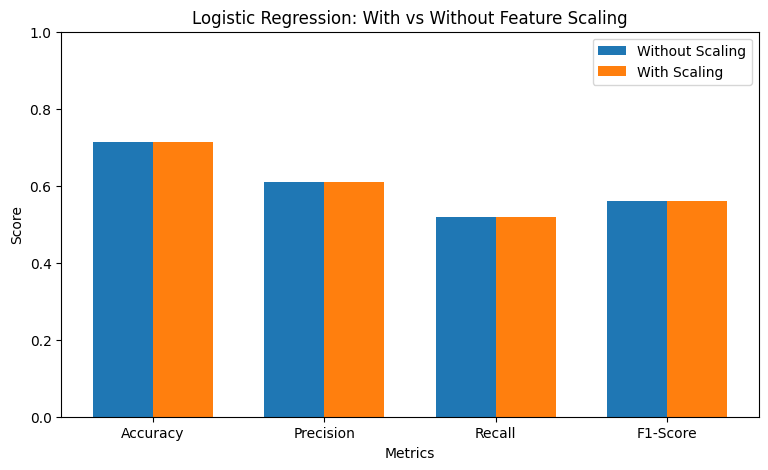

In [16]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

without_scaling = [
    accuracy_without_scaling,
    precision_without_scaling,
    recall_without_scaling,
    f1_without_scaling
]

with_scaling = [
    accuracy_with_scaling,
    precision_with_scaling,
    recall_with_scaling,
    f1_with_scaling
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, without_scaling, width, label="Without Scaling")
plt.bar(x + width/2, with_scaling, width, label="With Scaling")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Logistic Regression: With vs Without Feature Scaling")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()

plt.show()

In [17]:
print("Final Analysis")
print("==============")

if accuracy_with_scaling > accuracy_without_scaling:
    print("Feature scaling improved accuracy.")
elif accuracy_with_scaling < accuracy_without_scaling:
    print("Feature scaling reduced accuracy.")
else:
    print("Feature scaling produced the same accuracy.")

if f1_with_scaling > f1_without_scaling:
    print("Feature scaling improved the F1-score.")
elif f1_with_scaling < f1_without_scaling:
    print("Feature scaling reduced the F1-score.")
else:
    print("Feature scaling produced the same F1-score.")

print("\nWithout Scaling:")
print("Accuracy :", accuracy_without_scaling)
print("Precision:", precision_without_scaling)
print("Recall   :", recall_without_scaling)
print("F1-Score :", f1_without_scaling)

print("\nWith Scaling:")
print("Accuracy :", accuracy_with_scaling)
print("Precision:", precision_with_scaling)
print("Recall   :", recall_with_scaling)
print("F1-Score :", f1_with_scaling)

Final Analysis
Feature scaling produced the same accuracy.
Feature scaling produced the same F1-score.

Without Scaling:
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1-Score : 0.56

With Scaling:
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1-Score : 0.56
